In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
 
%matplotlib inline
sns.set(style="whitegrid", palette="muted")


In [22]:
df = pd.read_csv("../data/retail_store_sales_cleaned.csv",parse_dates=["transaction_date"])

print("Cleaned data loaded successfully!")

Cleaned data loaded successfully!


In [4]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 12575
Columns: 11


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12575 entries, 0 to 12574
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   transaction_id    12575 non-null  object 
 1   customer_id       12575 non-null  object 
 2   category          12575 non-null  object 
 3   item              12575 non-null  object 
 4   price_per_unit    12575 non-null  float64
 5   quantity          12575 non-null  int64  
 6   total_spent       12575 non-null  float64
 7   payment_method    12575 non-null  object 
 8   location          12575 non-null  object 
 9   transaction_date  12575 non-null  object 
 10  discount_applied  12575 non-null  bool   
dtypes: bool(1), float64(2), int64(1), object(7)
memory usage: 994.8+ KB


In [6]:
df.isnull().sum()

transaction_id      0
customer_id         0
category            0
item                0
price_per_unit      0
quantity            0
total_spent         0
payment_method      0
location            0
transaction_date    0
discount_applied    0
dtype: int64

In [7]:
desc = df[["price_per_unit", "quantity", "total_spent"]].agg(
    ["mean", "median", "std", "min", "max",
     lambda x: x.quantile(0.25), lambda x: x.quantile(0.75)]
)
desc.index = ["mean", "median", "std", "min", "max", "q1_25%", "q3_75%"]
desc


,price_per_unit,quantity,total_spent
mean,23.369304,5.552922,130.036938
median,23.000000,6.000000,110.000000
std,10.748728,2.790274,93.425533
min,5.000000,1.000000,5.000000
max,41.000000,10.000000,402.000000
q1_25%,14.000000,3.000000,52.000000
q3_75%,33.500000,8.000000,192.000000


In [8]:
print(df["category"].value_counts())
print()
print(df["payment_method"].value_counts())
print()
print(df["location"].value_counts())
print()
print(df["discount_applied"].value_counts())


category
Furniture                             1591
Electric household essentials         1591
Food                                  1588
Milk Products                         1584
Butchers                              1568
Beverages                             1567
Computers and electric accessories    1558
Patisserie                            1528
Name: count, dtype: int64

payment_method
Cash              4310
Digital Wallet    4144
Credit Card       4121
Name: count, dtype: int64

location
Online      6354
In-store    6221
Name: count, dtype: int64

discount_applied
False    8356
True     4219
Name: count, dtype: int64


. "Total spent ranges from 5 to 410 with a mean around 130. The 8 product categories are almost evenly represented, each with roughly 1,500-1,600 transactions."

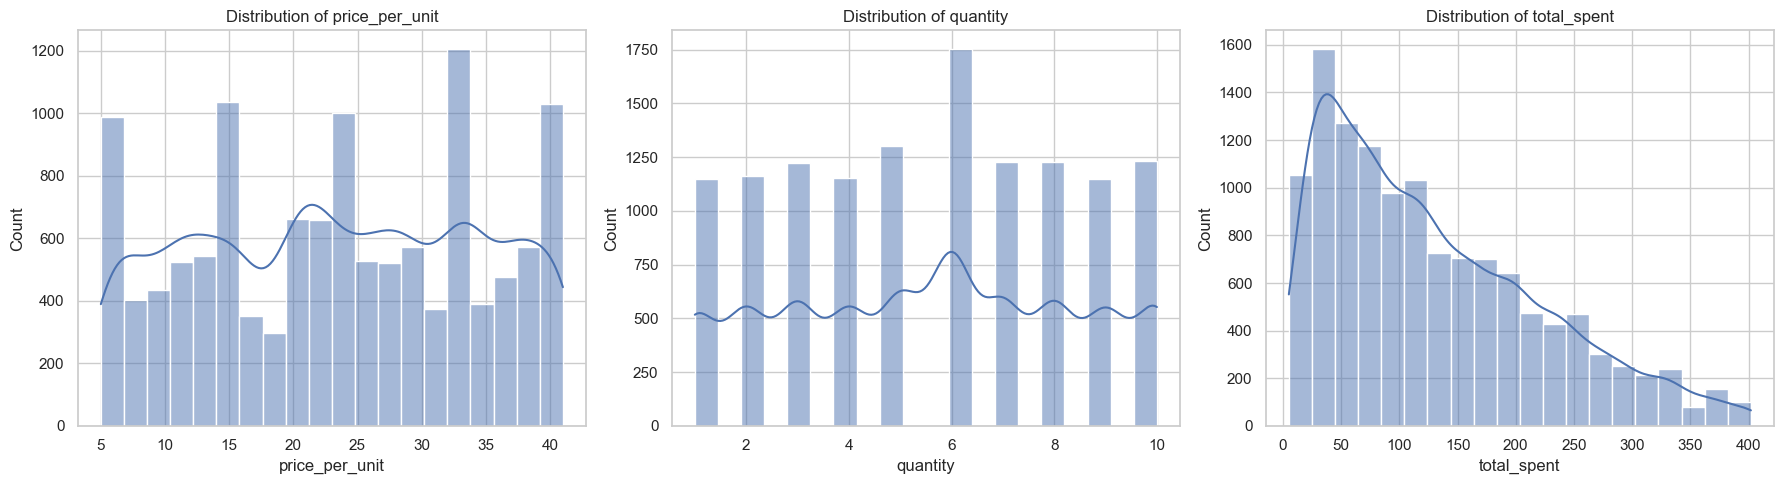

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, col in zip(axes, ["price_per_unit", "quantity", "total_spent"]):
    sns.histplot(df[col], kde=True, bins=20, ax=ax, color="#4C72B0")
    ax.set_title(f"Distribution of {col}")
plt.tight_layout()
plt.savefig("../screenshots/01_distributions_histograms_kde.png", dpi=150, bbox_inches="tight")
plt.show()


The retail store receives a large number of low-to-medium value transactions, while a smaller group of customers generates high sales revenue through larger purchases. Marketing strategies such as loyalty programs and targeted promotions could help increase average customer spending and overall revenue.

                price_per_unit  quantity  total_spent
price_per_unit        1.000000  0.010243     0.641103
quantity              0.010243  1.000000     0.704507
total_spent           0.641103  0.704507     1.000000


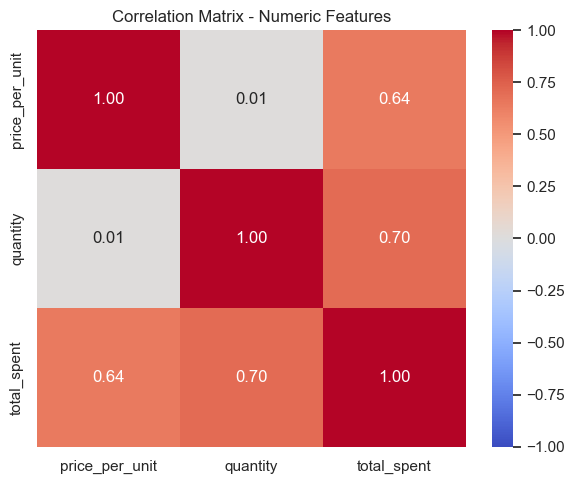

In [14]:
corr = df[["price_per_unit", "quantity", "total_spent"]].corr()
print(corr)
 
plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation Matrix - Numeric Features")
plt.tight_layout()
plt.savefig("../screenshots/02_correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()


### Correlation Analysis

* **Price per Unit vs Quantity (0.01):**
  There is almost **no correlation** between price per unit and quantity purchased. This indicates that customers buy similar quantities regardless of whether a product is relatively cheap or expensive.

* **Price per Unit vs Total Spent (0.64):**
  A **moderate positive correlation** exists between price per unit and total spending. As product prices increase, the total amount spent by customers generally tends to increase.

* **Quantity vs Total Spent (0.70):**
  There is a **strong positive correlation** between quantity purchased and total spending. Customers who buy more items tend to spend significantly more, making quantity one of the key drivers of revenue.

* **Overall Observation:**
  Both **price per unit** and **quantity** positively influence **total spending**, with quantity having a slightly stronger impact. This suggests that increasing the number of items purchased per transaction may be an effective strategy for boosting sales revenue.

### Business Insight

> The correlation matrix indicates that total spending is influenced more by the quantity of products purchased (0.70) than by product price (0.64). Therefore, strategies such as bundle offers, bulk discounts, and cross-selling may encourage customers to purchase more items and increase overall revenue.


C:\Users\samru\AppData\Local\Temp\ipykernel_161800\380493160.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="category", y="total_spent", data=df, palette="Set2")


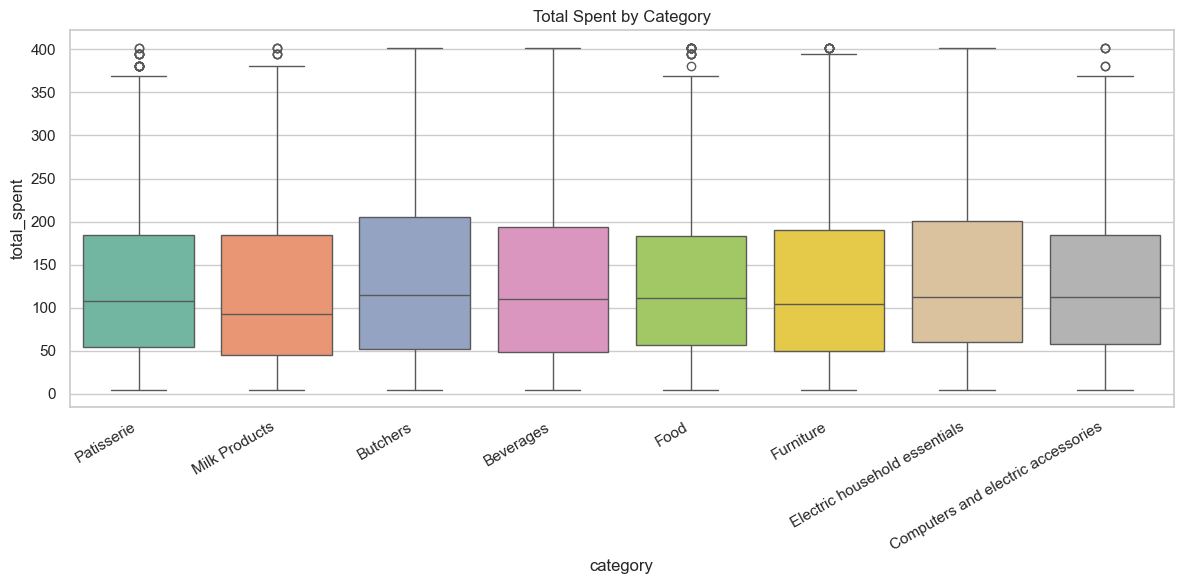

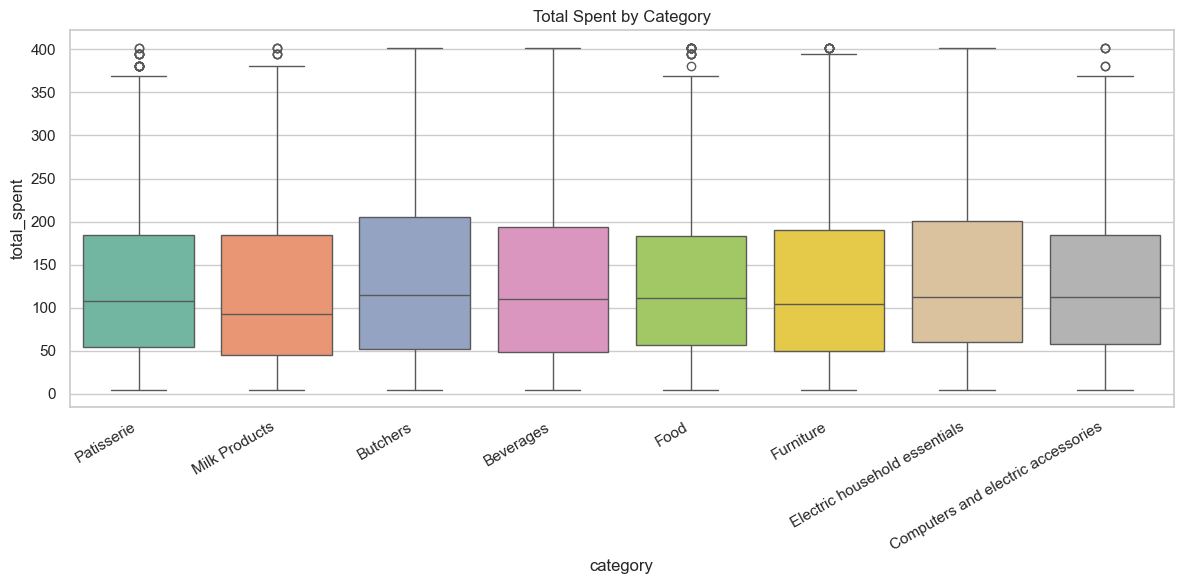

In [16]:
plt.figure(figsize=(12, 6))
sns.boxplot(x="category", y="total_spent", data=df, palette="Set2")
plt.xticks(rotation=30, ha="right")
plt.title("Total Spent by Category")
plt.tight_layout()
plt.savefig("../screenshots/03_boxplot_total_spent_by_category.png", dpi=150, bbox_inches="tight")
plt.show()


### Box Plot Analysis: Total Spent by Category

* The median **total spending** is fairly similar across all product categories, indicating consistent customer spending behavior.
* Categories such as **Butchers, Electric Household Essentials, and Computers & Electric Accessories** show slightly higher median spending compared to others.
* The spread of data (IQR) is similar across categories, suggesting comparable variability in customer purchases.
* Several **high-value outliers** are present in every category, indicating occasional large transactions.

### Business Insight

> Customer spending patterns are relatively consistent across categories, but certain categories generate slightly higher transaction values. High-value outliers suggest opportunities to target premium customers and promote higher-value purchases.


C:\Users\samru\AppData\Local\Temp\ipykernel_161800\1770633794.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="payment_method", y="total_spent", data=df, ax=axes[0], palette="Set3")
C:\Users\samru\AppData\Local\Temp\ipykernel_161800\1770633794.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="location", y="total_spent", data=df, ax=axes[1], palette="Pastel1")


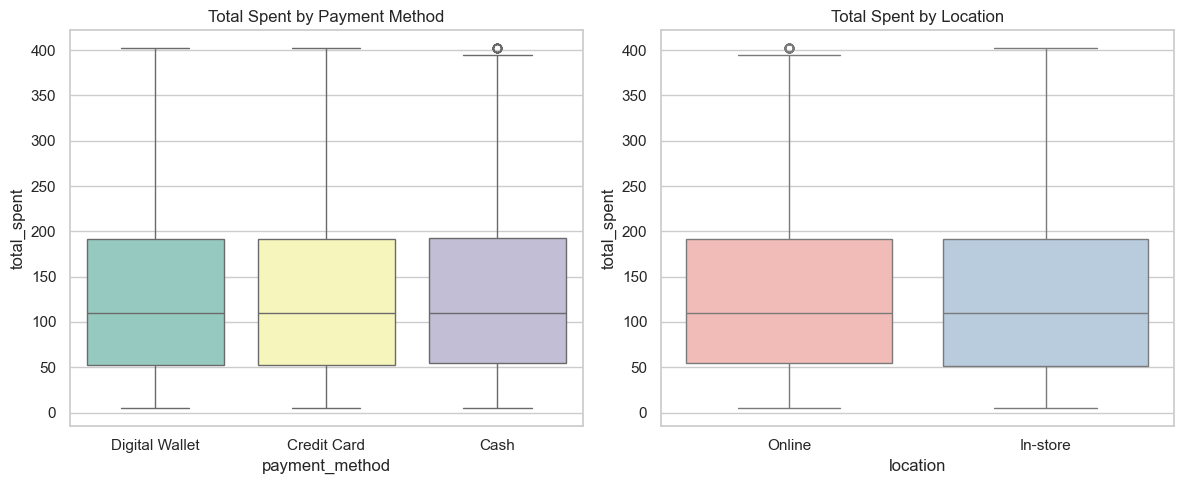

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.boxplot(x="payment_method", y="total_spent", data=df, ax=axes[0], palette="Set3")
axes[0].set_title("Total Spent by Payment Method")
 
sns.boxplot(x="location", y="total_spent", data=df, ax=axes[1], palette="Pastel1")
axes[1].set_title("Total Spent by Location")
plt.tight_layout()
plt.savefig("../screenshots/04_boxplot_payment_method_location.png", dpi=150, bbox_inches="tight")
plt.show()


### Box Plot Analysis: Total Spent by Payment Method and Location

* Customer spending patterns are **similar across all payment methods** (Digital Wallet, Credit Card, and Cash), with comparable median values and variability.
* Both **Online and In-store** purchases show nearly identical spending distributions, indicating no significant difference in transaction value based on shopping location.
* A few **high-spending outliers** are present across all payment methods and locations, representing customers with exceptionally large purchases.

### Business Insight

> Since spending behavior is consistent across payment methods and shopping channels, businesses can focus on improving customer experience across all platforms rather than prioritizing a specific payment option or sales channel.


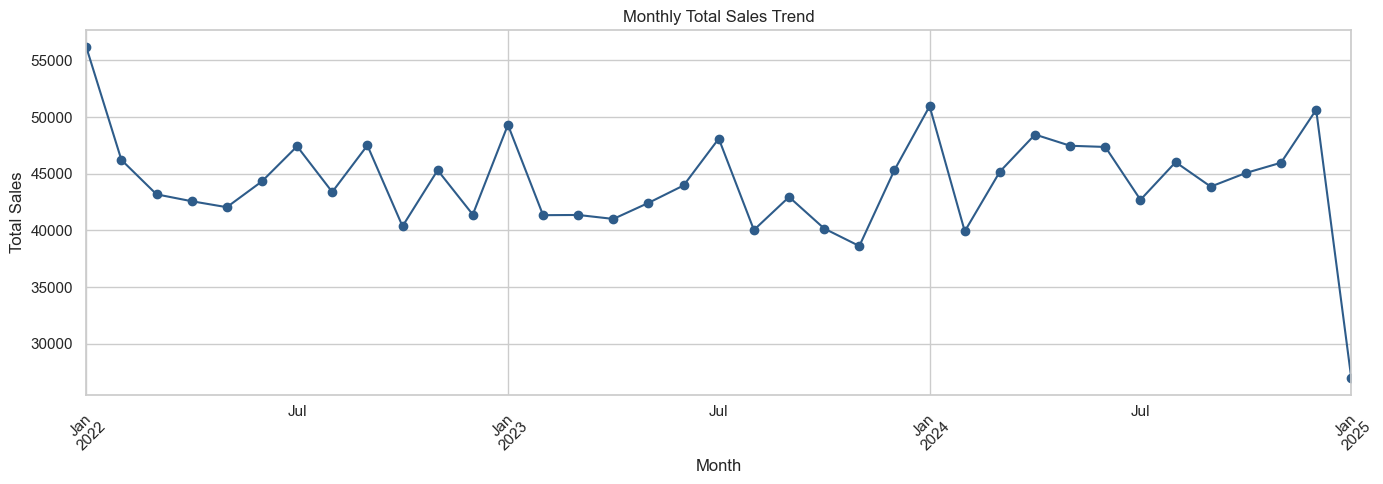

In [23]:
df["year_month"] = df["transaction_date"].dt.to_period("M")
 
monthly_sales = df.groupby("year_month")["total_spent"].sum()
 
plt.figure(figsize=(14, 5))
monthly_sales.plot(kind="line", marker="o", color="#2E5C8A")
plt.title("Monthly Total Sales Trend")
plt.ylabel("Total Sales")
plt.xlabel("Month")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("../screenshots/05_monthly_sales_trend.png", dpi=150, bbox_inches="tight")
plt.show()


### Monthly Sales Trend Analysis

* Monthly sales remain **relatively stable** throughout the period, generally ranging between **40,000 and 50,000**, indicating consistent business performance.
* Several months show noticeable **sales peaks**, suggesting periods of higher customer demand or successful promotional activities.
* A slight decline is observed in some months, but overall there is **no strong long-term upward or downward trend**.
* The sharp drop in the final month is likely due to **incomplete data collection for that month** rather than an actual decrease in sales.

### Business Insight

> The business demonstrates stable sales performance with periodic peaks in demand. Identifying the factors behind high-sales months can help replicate successful strategies and further improve revenue growth.


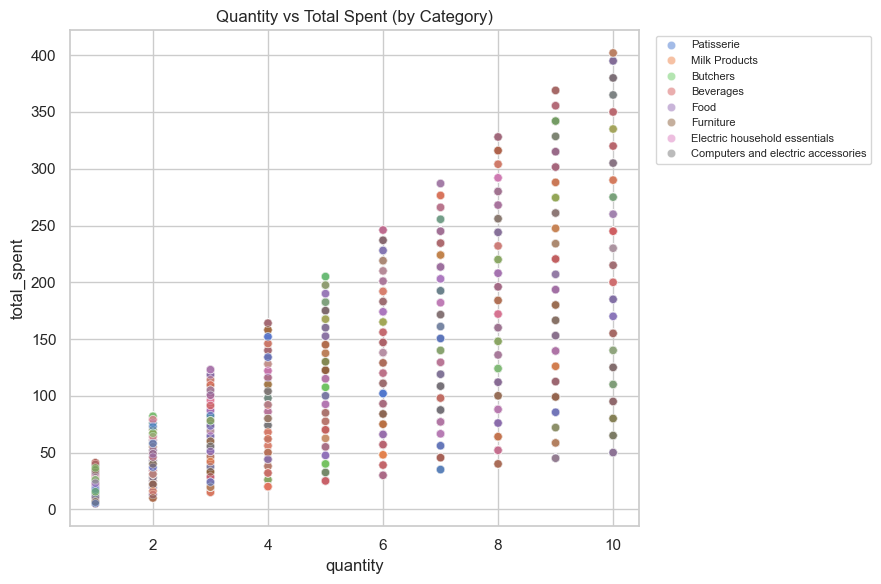

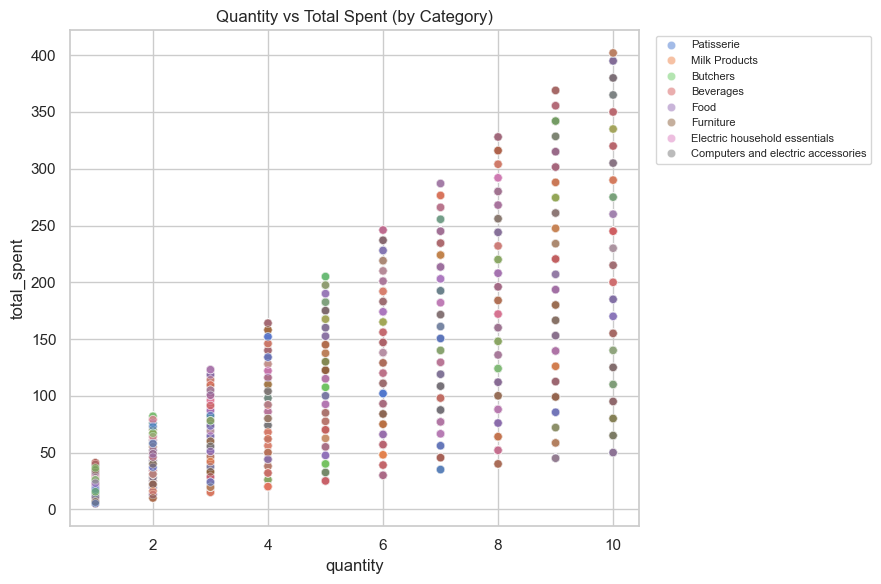

In [25]:
plt.figure(figsize=(9, 6))
sns.scatterplot(x="quantity", y="total_spent", hue="category", data=df, alpha=0.5)
plt.title("Quantity vs Total Spent (by Category)")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.savefig("../screenshots/08_scatter_quantity_vs_total_spent.png", dpi=150, bbox_inches="tight")
plt.show()


### Scatter Plot Analysis: Quantity vs Total Spent

* A clear **positive relationship** exists between quantity purchased and total spending, as higher quantities generally result in higher transaction values.
* The upward trend is consistent across all product categories, indicating that quantity is a major driver of sales revenue.
* Some categories show higher spending for the same quantity level, suggesting differences in product pricing.
* No major anomalies are observed, and the relationship appears strong and predictable.

### Business Insight

> Customers who purchase more items tend to spend significantly more. Encouraging larger basket sizes through bundle offers, volume discounts, and cross-selling strategies can help increase overall revenue.


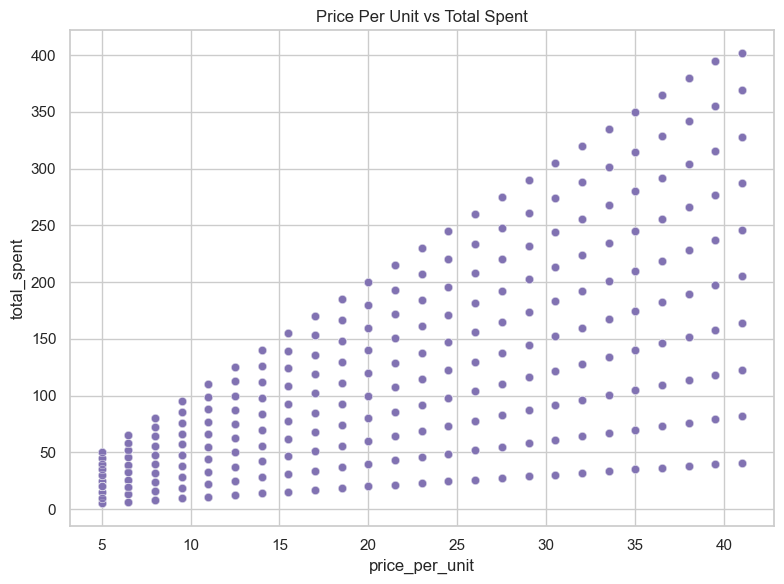

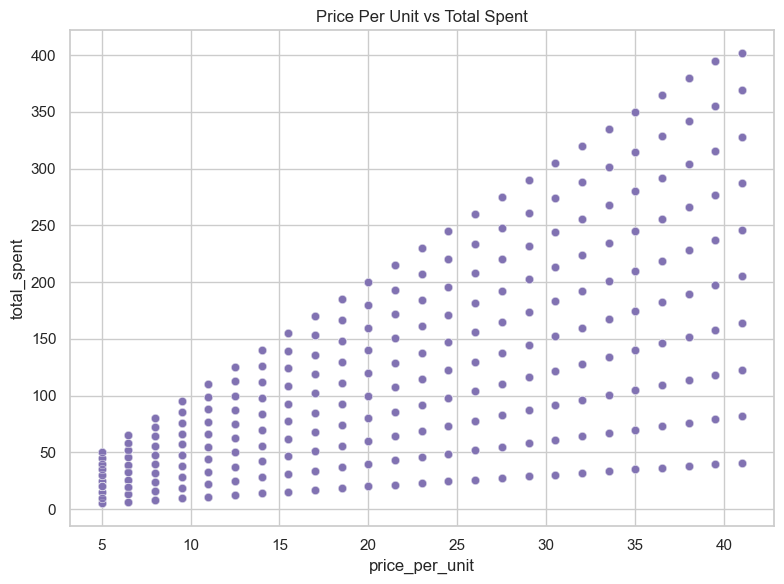

In [27]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x="price_per_unit", y="total_spent", data=df, alpha=0.4, color="#8172B2")
plt.title("Price Per Unit vs Total Spent")
plt.tight_layout()
plt.savefig("../screenshots/09_scatter_price_vs_total_spent.png", dpi=150, bbox_inches="tight")
plt.show()


### Scatter Plot Analysis: Price per Unit vs Total Spent

* A clear **positive relationship** exists between product price and total spending, with higher-priced items generally resulting in higher transaction values.
* Total spending increases steadily as the price per unit increases, indicating that product pricing has a direct impact on revenue.
* The spread of points widens at higher price levels because total spending is also influenced by the quantity purchased.
* No significant anomalies or unusual patterns are observed, suggesting a consistent relationship between price and spending.

### Business Insight

> Higher-priced products contribute significantly to total revenue. Promoting premium products and optimizing pricing strategies can help increase overall sales while maintaining customer demand.


# Key Business Insights

### 1. Category Performance
Sales are well distributed across all eight product categories, with no single category overwhelmingly dominating the market. This indicates a balanced product portfolio and reduces dependency on any one category for revenue generation.

### 2. Quantity Has the Strongest Impact on Revenue
The correlation analysis shows that quantity purchased has a strong positive relationship with total spending (correlation ≈ 0.70). Customers who buy more items consistently generate higher revenue, making basket size an important driver of sales performance.

### 3. Product Price Also Influences Spending
Price per unit has a moderate positive correlation with total spending (correlation ≈ 0.64). Higher-priced products contribute significantly to revenue, suggesting that premium products play an important role in overall sales.

### 4. Similar Spending Across Channels and Payment Methods
The analysis of Online vs In-store purchases and different payment methods shows very similar spending patterns. This suggests that customers exhibit comparable purchasing behavior regardless of shopping channel or payment option.

### 5. Stable Sales Trend Over Time
Monthly sales remain relatively stable throughout the observed period, generally ranging between 40,000 and 50,000. While some months experience sales peaks, there is no significant long-term decline, indicating consistent business performance.

# Conclusion and Business Recommendations

## What We Found
The exploratory data analysis revealed that total spending is primarily influenced by the quantity of products purchased and, to a lesser extent, product price. Sales performance remains stable over time, and revenue is distributed fairly evenly across product categories.

## Why It Matters
Understanding the factors that drive customer spending helps the business make informed decisions regarding inventory management, pricing strategies, and promotional campaigns. Since quantity purchased has the strongest impact on revenue, increasing basket size can directly improve sales performance.

## Recommendations

1. Introduce bundle offers and volume discounts to encourage customers to purchase more items per transaction.
2. Continue promoting higher-priced products that contribute significantly to revenue while maintaining competitive pricing.
3. Maintain balanced inventory levels across all categories since sales are distributed relatively evenly.
4. Analyze the causes behind high-sales months and replicate successful promotional strategies during future campaigns.
5. Enhance customer loyalty programs to increase repeat purchases and average order value.
